# Chapter 6 — Stochastic Processes & AR/ARMA Modelling

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch06_stochastic_ar.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch06_stochastic_ar.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch06_stochastic_ar.ipynb)

> **Motivating question.** Biosignals are partly random — how do we describe and model that randomness usefully?

## What this notebook demonstrates

- Stationarity: strict, wide-sense, and local/quasi-stationary
- Autocorrelation, PACF, and the Wiener–Khinchin theorem
- AR / MA / ARMA models as compact signal descriptions
- Order selection with AIC / MDL
- Why a global spectrum hides 30-second stage changes (student task)

## What you'll do

You'll compare the autocorrelation of a periodic signal against noise, read an AR model's order straight off an ACF/PACF pair, then sweep the AR order on an EEG spectrum and watch it go from under- to over-fit.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [ ]:
import numpy as np
from scipy.signal import find_peaks, freqz, welch

CH = 6


def biased_acf(x, maxlag, unbiased=False):
    """Normalized autocorrelation for lags 0..maxlag.

    Biased (default, /n) applies a triangular taper that damps high-lag values —
    fine for estimation, but it makes an *ideal* undamped signal appear to decay.
    Pass unbiased=True (/ (n-k)) when illustrating that a periodic signal's ACF
    does *not* decay."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    full = np.correlate(x, x, mode="full")
    mid = n - 1
    r = full[mid:mid + maxlag + 1].astype(float)
    if unbiased:
        r /= (n - np.arange(maxlag + 1))
    else:
        r /= n
    return r / r[0]


def yule_walker(x, order):
    """Yule-Walker AR estimate. Returns (a-coeffs, sigma2)."""
    x = np.asarray(x, float)
    x = x - x.mean()
    r = biased_acf(x, order) * np.var(x)          # un-normalize to covariance
    R = np.array([[r[abs(i - j)] for j in range(order)] for i in range(order)])
    rhs = r[1:order + 1]
    a = np.linalg.solve(R, rhs)
    sigma2 = r[0] - a @ rhs
    return a, sigma2


def pacf_from_yw(x, maxlag):
    """PACF via Levinson-Durbin: phi_kk for k = 1..maxlag."""
    x = np.asarray(x, float)
    r = biased_acf(x, maxlag)
    pacf = np.zeros(maxlag + 1)
    pacf[0] = 1.0
    phi = np.zeros((maxlag + 1, maxlag + 1))
    phi[1, 1] = r[1]
    pacf[1] = r[1]
    E = 1 - r[1] ** 2
    for k in range(2, maxlag + 1):
        num = r[k] - np.sum(phi[k - 1, 1:k] * r[k - 1:0:-1])
        phi[k, k] = num / E if E > 0 else 0.0
        for j in range(1, k):
            phi[k, j] = phi[k - 1, j] - phi[k, k] * phi[k - 1, k - j]
        E *= (1 - phi[k, k] ** 2)
        pacf[k] = phi[k, k]
    return pacf


def ar_spectrum(a, sigma2, fs, nfft=1024):
    """Parametric AR PSD (sigma2/|A(f)|^2). Delegates to the single tested helper
    bsp.ar_psd (Appendix H) so there is one correct implementation of the
    freqz-based recipe, not a copy that could be re-broken into its reciprocal."""
    return bio.ar_psd(a, sigma2, fs, nfft)

## 6.1 ACF: periodic signal vs white noise

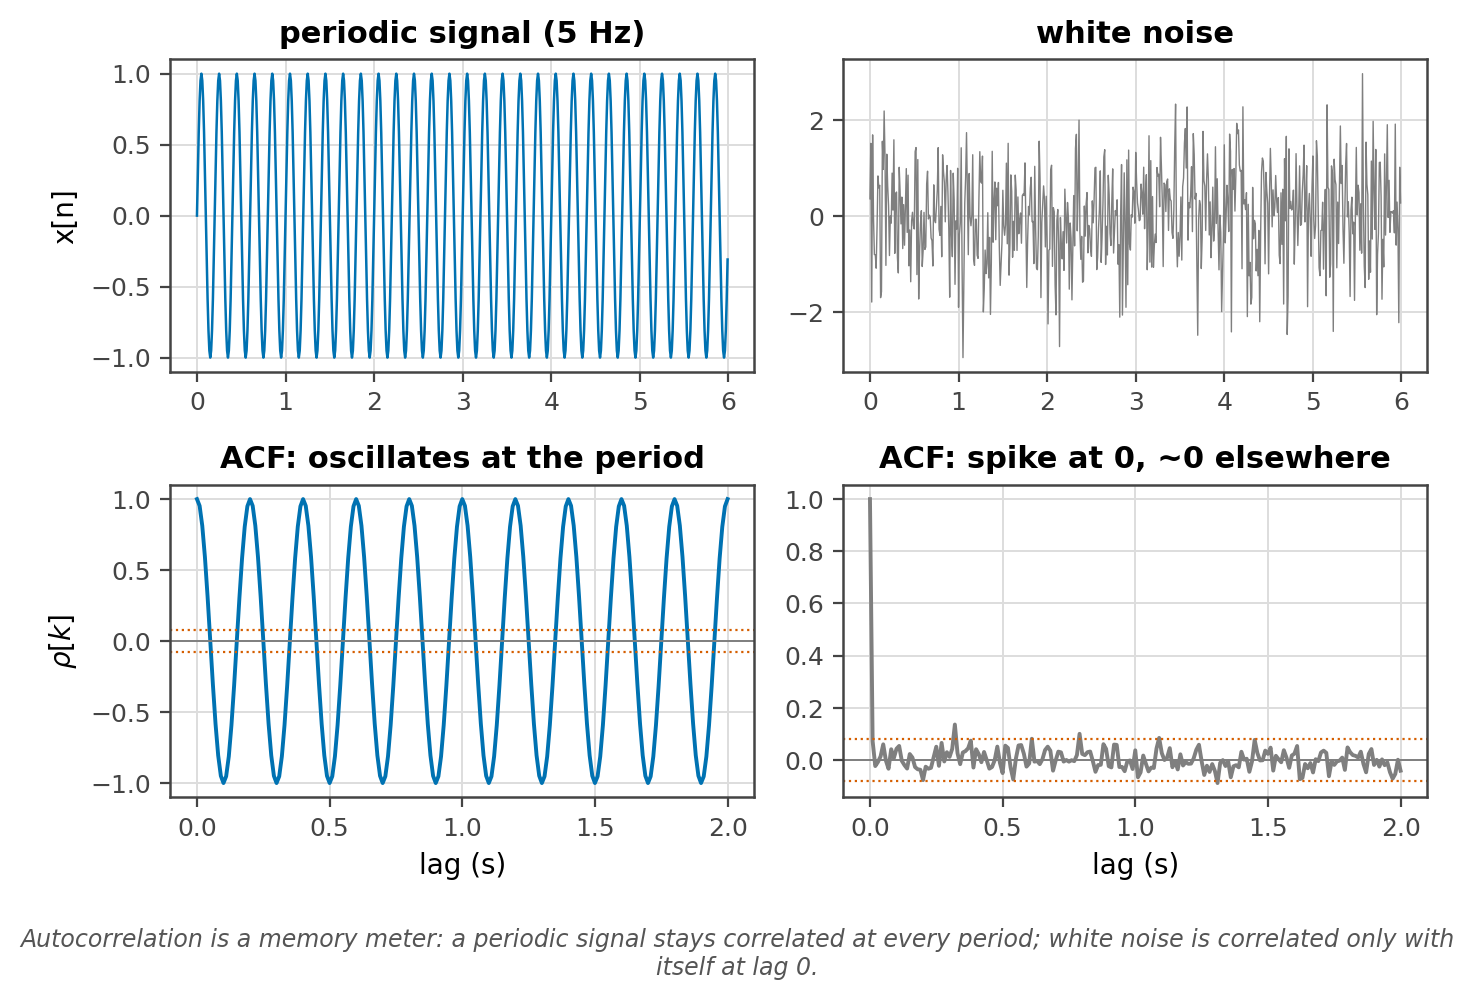

In [3]:
fs = 100.0
n = 600
t = np.arange(n) / fs
f0 = 5.0
periodic = np.sin(2 * np.pi * f0 * t)
noise = bio.white(n, seed=21)

maxlag = 200
lags = np.arange(maxlag + 1) / fs
r_per = biased_acf(periodic, maxlag, unbiased=True)   # ideal signal: no taper -> does not decay
r_noi = biased_acf(noise, maxlag)

fig, axes = bs.newfig(w=7.2, h=4.6, nrows=2, ncols=2)
axes[0, 0].plot(t, periodic, color=bs.C['blue'], lw=0.9)
axes[0, 0].set_title("periodic signal (5 Hz)")
axes[0, 0].set_ylabel("x[n]")
axes[0, 1].plot(t, noise, color=bs.C['grey'], lw=0.5)
axes[0, 1].set_title("white noise")

axes[1, 0].plot(lags, r_per, color=bs.C['blue'])
axes[1, 0].set_title("ACF: oscillates at the period")
axes[1, 0].set_xlabel("lag (s)"); axes[1, 0].set_ylabel(r"$\rho[k]$")
axes[1, 0].axhline(0, color=bs.C['grey'], lw=0.7)

axes[1, 1].plot(lags, r_noi, color=bs.C['grey'])
axes[1, 1].set_title("ACF: spike at 0, ~0 elsewhere")
axes[1, 1].set_xlabel("lag (s)")
axes[1, 1].axhline(0, color=bs.C['grey'], lw=0.7)
ci = 1.96 / np.sqrt(n)
for ax in (axes[1, 0], axes[1, 1]):
    ax.axhline(ci, color=bs.C['red'], ls=':', lw=0.8)
    ax.axhline(-ci, color=bs.C['red'], ls=':', lw=0.8)

bs.takeaway(fig, "Autocorrelation is a memory meter: a periodic signal "
                 "stays correlated at every period; white noise is "
                 "correlated only with itself at lag 0.")
plt.tight_layout()
plt.show()

## 6.2 ACF and PACF of an HRV tachogram

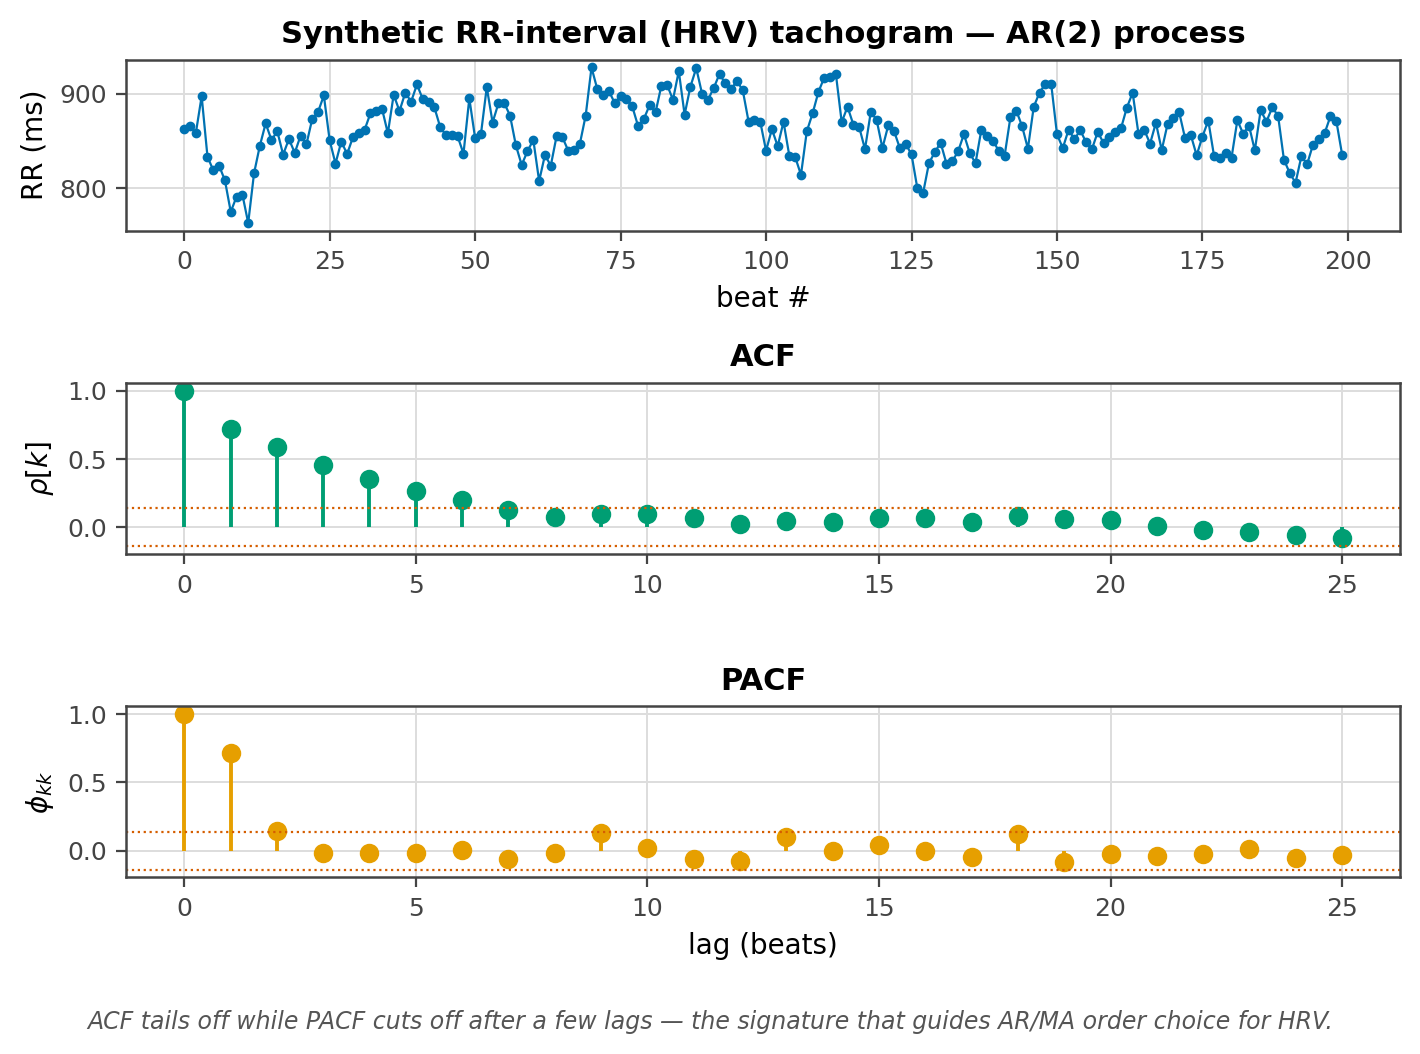

In [4]:
# A synthetic RR tachogram driven by an explicit AR(2) process, so it shows the
# genuine "ACF tails off, PACF cuts off" AR signature. (Deriving RR from ECG
# R-peak detection instead injects a negative-lag-1 quantization artifact that
# reads as MA, not AR — the wrong signature for this teaching figure.)
rng = np.random.default_rng(6)
n_beats = 200
a1, a2 = 0.5, 0.2                          # stable AR(2), real roots -> decaying ACF
e = rng.standard_normal(n_beats + 100)
y = np.zeros(n_beats + 100)
for k in range(2, len(y)):
    y[k] = a1 * y[k - 1] + a2 * y[k - 2] + e[k]
y = y[100:]                                # discard burn-in
rr = 860.0 + 30.0 * y / np.std(y)          # ms tachogram: mean ~860, SD ~30

maxlag = 25
acf = biased_acf(rr, maxlag)
pacf = pacf_from_yw(rr, maxlag)
lags = np.arange(maxlag + 1)
ci = 1.96 / np.sqrt(len(rr))

fig, axes = bs.newfig(w=7.2, h=5.0, nrows=3, ncols=1)
axes[0].plot(np.arange(len(rr)), rr, color=bs.C['blue'], marker='o',
             ms=2.5, lw=0.8)
axes[0].set_title("Synthetic RR-interval (HRV) tachogram — AR(2) process")
axes[0].set_xlabel("beat #"); axes[0].set_ylabel("RR (ms)")

axes[1].stem(lags, acf, linefmt=bs.C['green'], markerfmt='o', basefmt=' ')
axes[1].axhline(ci, color=bs.C['red'], ls=':', lw=0.8)
axes[1].axhline(-ci, color=bs.C['red'], ls=':', lw=0.8)
axes[1].set_title("ACF")
axes[1].set_ylabel(r"$\rho[k]$")

axes[2].stem(lags, pacf, linefmt=bs.C['orange'], markerfmt='o', basefmt=' ')
axes[2].axhline(ci, color=bs.C['red'], ls=':', lw=0.8)
axes[2].axhline(-ci, color=bs.C['red'], ls=':', lw=0.8)
axes[2].set_title("PACF")
axes[2].set_xlabel("lag (beats)"); axes[2].set_ylabel(r"$\phi_{kk}$")

bs.takeaway(fig, "ACF tails off while PACF cuts off after a few lags — the "
                 "signature that guides AR/MA order choice for HRV.")
plt.tight_layout()
plt.show()

## 6.3 AR spectrum of a waking EEG epoch

In [ ]:
fs = 100.0
t, x = bio.eeg(duration=30.0, fs=fs, stage="W")   # 'W' has a clear alpha peak
x = x - x.mean()

order = 12
a, sigma2 = yule_walker(x, order)
f_ar, psd_ar = ar_spectrum(a, sigma2, fs, nfft=2048)

# A raw periodogram for comparison (to show the AR peak is real, not noise).
# scipy's one-sided Welch periodogram (nperseg = full length -> a single
# Hann-windowed periodogram) so its scaling matches bio.ar_psd's one-sided AR
# PSD. A hand-rolled two-sided |X|^2/(fs*sum(w^2)) periodogram integrates to
# var/2 and would show a spurious ~3 dB offset against the one-sided AR curve.
f_pg, pg = welch(x, fs, window="hann", nperseg=len(x), detrend=False)

# locate the AR alpha peak
band = (f_ar >= 6) & (f_ar <= 14)
pk_f = f_ar[band][np.argmax(psd_ar[band])]

fig, axes = bs.newfig(w=7.2, h=4.4, nrows=2, ncols=1)
axes[0].plot(t, x, color=bs.C['blue'], lw=0.6)
axes[0].set_title("EEG epoch (waking, alpha rhythm present)")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("amp")
axes[0].set_xlim(0, 6)

axes[1].semilogy(f_pg, pg, color=bs.C['lightgrey'], lw=0.7,
                 label="periodogram (noisy)")
axes[1].semilogy(f_ar, psd_ar, color=bs.C['red'], lw=1.6,
                 label=f"AR({order}) spectrum")
axes[1].axvline(pk_f, color=bs.C['green'], ls='--', lw=1.0)
axes[1].annotate(f"alpha peak ~ {pk_f:.1f} Hz",
                 xy=(pk_f, np.max(psd_ar[band])),
                 xytext=(pk_f + 6, 0.3 * np.max(psd_ar[band])),
                 fontsize=9, color=bs.C['green'])
axes[1].set_xlim(0, 40)
axes[1].set_title("AR spectrum: smooth, high-resolution peak")
axes[1].set_xlabel("frequency (Hz)"); axes[1].set_ylabel("PSD")
axes[1].legend(loc="upper right")

bs.takeaway(fig, "An all-pole AR model turns a noisy epoch into a smooth "
                 "spectrum with a sharp alpha peak — poles sit near the "
                 "dominant rhythm; the second peak at ~22 Hz is the "
                 "synthetic beta component.")
plt.tight_layout()
plt.show()

## Order selection with BIC

How many AR poles does this same epoch actually need? Fit orders 1–30 with `yule_walker` and score each with the Bayesian Information Criterion (BIC = `n·log(σ²) + p·log(n)`, Schwarz's criterion) — it penalizes extra parameters more than AIC, so its minimum marks a good order without over-fitting.

In [ ]:
orders = np.arange(1, 31)
bic = []
for p in orders:
    a_p, s2_p = yule_walker(x, p)
    bic.append(len(x) * np.log(s2_p) + p * np.log(len(x)))
bic = np.array(bic)
p_best = orders[np.argmin(bic)]

fig, ax = bs.newfig(w=6.0, h=3.2)
ax.plot(orders, bic, color=bs.C['blue'], marker='o', ms=3, lw=1.0)
ax.axvline(p_best, color=bs.C['red'], ls='--', lw=1.0)
ax.set_title(f"BIC vs AR order — minimum at p = {p_best}")
ax.set_xlabel("AR order p"); ax.set_ylabel("BIC")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `[a,e] = aryule(x,p)`; `parcorr(x)`; `aic`/`bic` for order.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Copy the 6.3 cell and loop `order` in `(2, 4, 12, 40)`; overlay the spectra. At which order does the 22 Hz beta peak appear? At which order does the first peak *not* at 10 or 22 Hz appear?

<details><summary>💡 Hint &amp; what you should see</summary>

Too-low AR order → over-smoothed spectrum (misses peaks); too-high → **spurious** peaks fitting noise. AIC/MDL pick the knee — watch peaks appear, then fragment, as the order climbs.

</details>

**2.** Concatenate `bio.eeg(stage='W')` and `bio.eeg(stage='N3')` (30 s each). Compute `biased_acf(..., maxlag=100)` on the first 30 s, the last 30 s, and the full 60 s; report ρ at lag 0.1 s for each and explain why the global value lies between the other two.

<details><summary>💡 Hint &amp; what you should see</summary>

A stationary signal's ACF depends only on lag (decays cleanly); a non-stationary one's ACF changes with position. A single global ACF **blurs** the 30-s stage changes — which motivates windowing.

</details>

In [6]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch06_figures.py`.*